In [1]:
from pharos_hls.pharos_hls import PharosHLS

In [2]:
pharos_hls = PharosHLS("case_study_1_conv2d")

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "dim": Param(range=(8, 50)),
    "kernel": Param(range=(2, 5), constraints=[LessThan("dim")]),
    "stride": Param(range=(1, 5)),
    "padding": Param(range=(0, 4), constraints=[LessThan("kernel")]),
    "ch_in": Param(range=(1, 16)),
    "ch_out": Param(range=(1, 16)),
    "quant": Param(range=(2, 16))
}

function_params = {
    "input": FunctionParam(("ch_in", "dim"), lambda ch_in, dim: (ch_in, dim, dim), input_or_output=True),
    "output": FunctionParam(("ch_out", "dim", "padding", "stride", "kernel"), lambda co, dim, p, s, k: (co, (dim - k + 2 * p) // s + 1, (dim - k + 2 * p) // s + 1), input_or_output=True),
    "weight": FunctionParam(("ch_out", "ch_in", "kernel"), lambda co, ci, k: (co, ci, k, k)),
    "bias": FunctionParam("ch_out", lambda co: co)
}

In [ ]:
pharos_hls.define_function_to_explore("Conv2d",
                                      "simple_conv_2d.h",
                                      params,
                                      function_params,
                                      ("kernel", "padding", "dim", "ch_in", "ch_out", "stride"))

In [ ]:
pharos_hls.explore_synth(frequency_MHz=100, number_of_samples=1000, part="xcu250-figd2104-2L-e")

In [ ]:
pharos_hls.print_synth_results("Conv2d", "xcu250-figd2104-2L-e")

In [4]:
df = pharos_hls.get_synth_results("Conv2d", "xcu250-figd2104-2L-e")

In [5]:
cols_X = df.columns[:7]
cols_Y = df.columns[7:]

print(cols_X)
print(cols_Y)

Index(['ch_in', 'ch_out', 'dim', 'kernel', 'padding', 'quant', 'stride'], dtype='object')
Index(['BRAM_18K', 'DSP', 'FF', 'LUT', 'avg_total_cycles',
       'estimated_clock_period'],
      dtype='object')


In [19]:
def get_correlations(cols_X, cols_Y, n_linhas=None, method="kendall"):

    if n_linhas is not None:
        df_subset = df.head(n_linhas)
    else:
        df_subset = df

    correlacoes = pd.DataFrame(index=cols_X, columns=cols_Y)

    for col_x in cols_X:
        
        for col_y in cols_Y:
            correlacoes.loc[col_x, col_y] = round(df_subset[col_x].corr(df_subset[col_y], method=method), 2)

    return correlacoes

conv_resource = get_correlations(cols_X, cols_Y)
resource_resource = get_correlations(cols_Y[:-2], cols_Y[:-2])

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
def explore_num_lines(cols_X, cols_Y):

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2 linhas, 5 colunas
    axes = axes.flatten()

    for i in range(10):
        samples = 100 * (i + 1)

        corr = get_correlations(cols_X, cols_Y, samples, "kendall")

        sns.heatmap(
            corr.astype(float),
            annot=True,
            cmap="coolwarm",
            ax=axes[i],
            cbar=False  # evita várias barras de cor
        )

        axes[i].set_title(f"{samples} amostras")

    plt.tight_layout()
    plt.show()

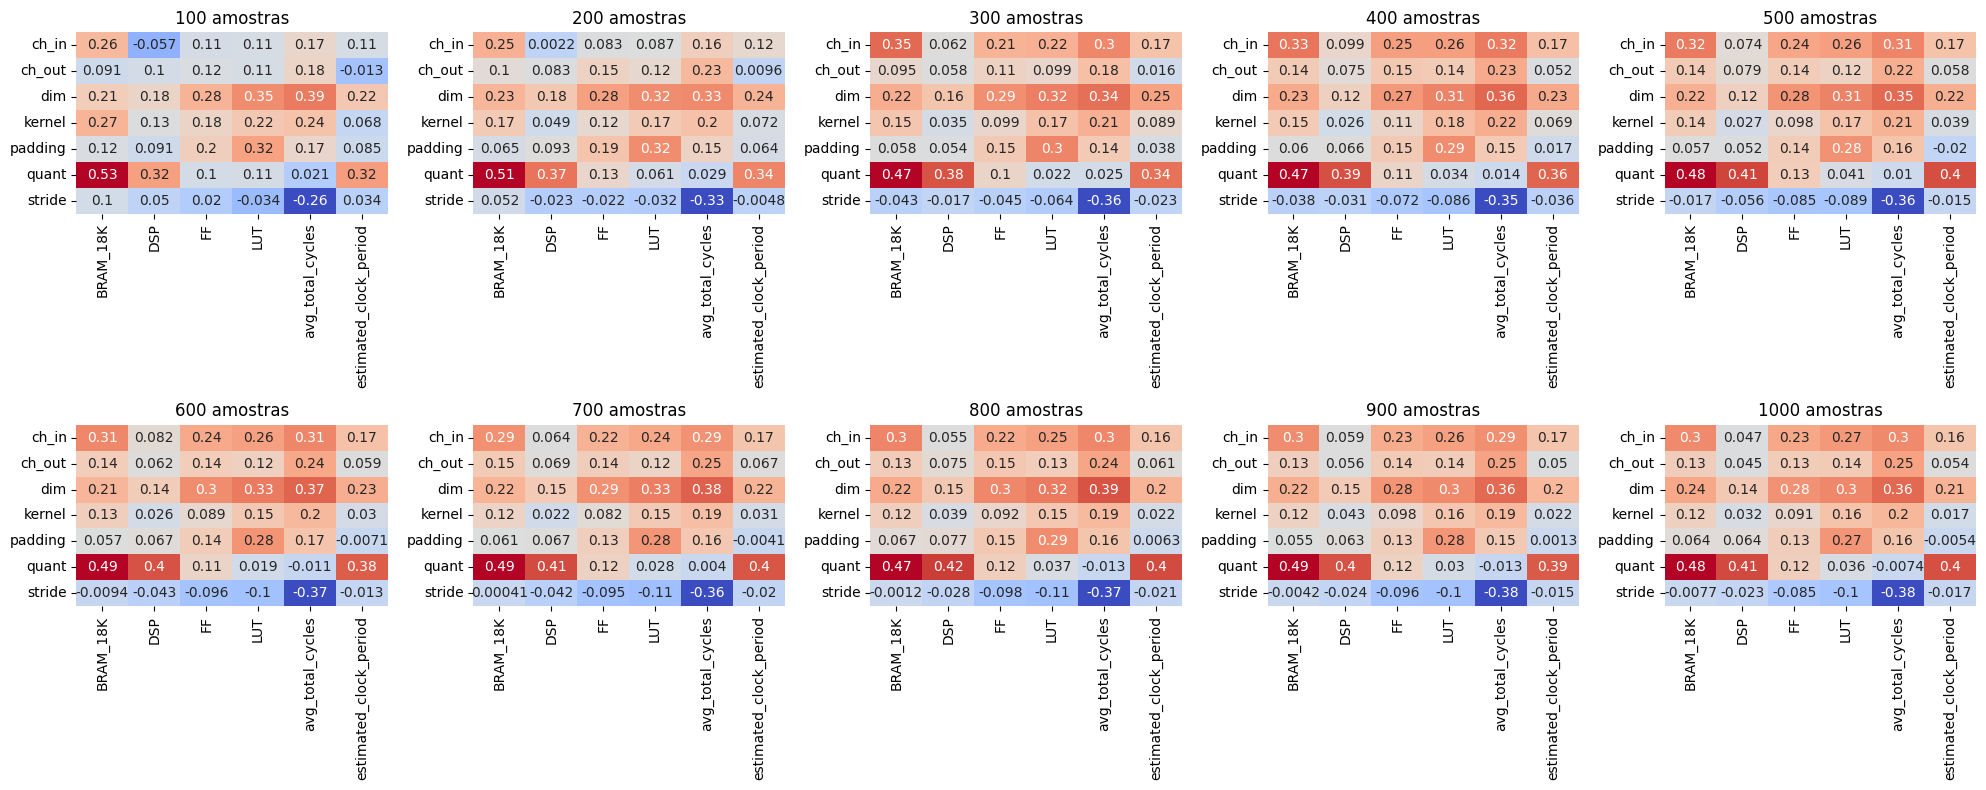

In [10]:
explore_num_lines(cols_X, cols_Y)

In [8]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

def linearity_r2(x, y):
    x = np.array(x).reshape(-1, 1)

    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)

    return r2_score(y, y_pred)

In [9]:
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
import numpy as np

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def curvature_index(a, b, x):
    x = np.array(x)

    f1 = np.abs(2*a*x + b)
    f2 = np.abs(2*a)

    return np.mean(f2 / (f1 + 1e-8))

def get_best_fit_func(X, y):

    # funções candidatas
    def linear(x, a, b):
        return a*x + b

    def exponencial(x, a, b):
        return a * np.exp(b*x)

    def quadratic(x, a, c):
        return a * x * x + c
    
    def inverse(x, a):
        return a / x
    
    def inverse_sq(x, a):
        return a / (x * x)
    
    # def log(x, a):
    #     return a * np.log(x)

    modelos = {
        "linear": linear,
        # "exponencial": exponencial,
        "quad": quadratic,
        "inv": inverse,
        "inv_sq": inverse_sq
    }

    best_func = None
    best_func_name = ""
    best_func_params = None

    # print(f"linearity: {linearity_r2(X, y)}")

    menor_erro = float("inf")

    for nome, func in modelos.items():
        try:
            params, _ = curve_fit(func, X, y)
            y_pred = func(X, *params)
            # erro = mean_squared_error(y, y_pred)
            erro = mape(y, y_pred)

            # if nome == "quad":
            #     erro *= 1.1

            #     print(f"simple linearity check: {curvature_index(params[0], params[1], 16)}")

            if erro < menor_erro:
                menor_erro = erro

                best_func_name = nome
                best_func = func
                best_func_params = params

            # print(f"{nome} -> error: {erro}")

        except:
            continue

    return best_func_name, best_func, best_func_params

In [10]:
def group_table(a, b):
    
    agg_table = (
        df.groupby(a)[b]
        .mean()
        .reset_index(name="mean")
        .rename(columns={a: "key"})
    )

    return agg_table.sort_values("key")


In [59]:
# sns.heatmap(conv_resource.astype(float), annot=True, cmap="coolwarm")
# plt.show()

In [11]:
def plot_relation(a, b):

    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    agg = group_table(a, b)

    plt.figure(figsize=(8, 5))
    plt.plot(agg["key"], agg["mean"], marker="o")

    ax = plt.gca()

    ax.xaxis.set_major_locator(ticker.MaxNLocator(
        integer=True,
        nbins=10  # máximo de ticks visíveis
    ))

    plt.xlabel(a)
    plt.ylabel(b)

    plt.grid(True)
    plt.show()

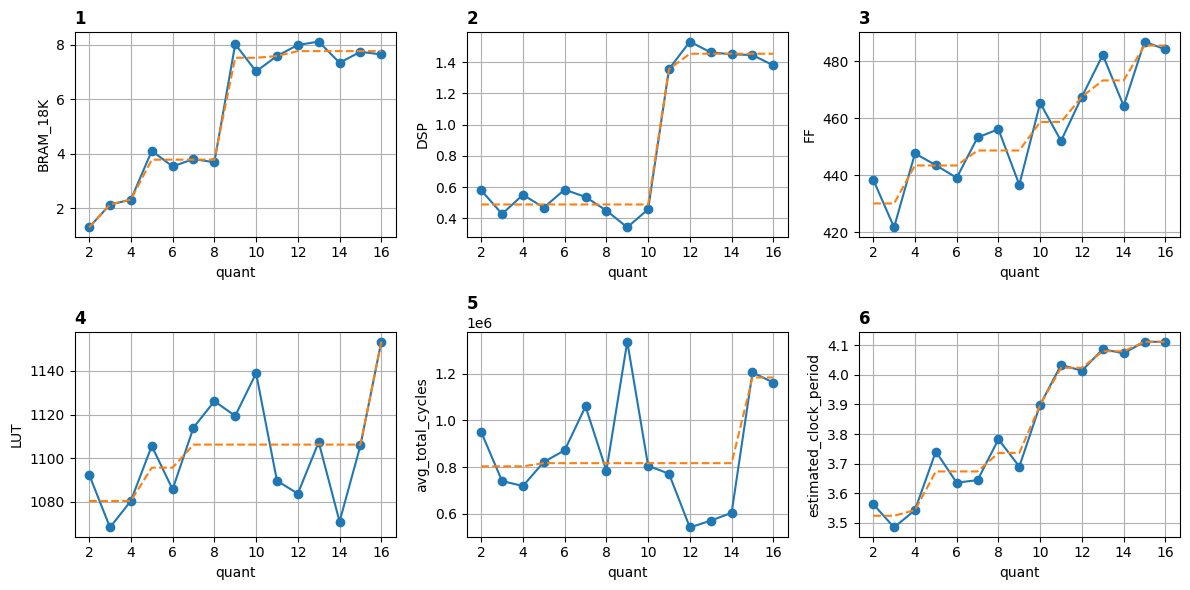

In [15]:
import matplotlib.ticker as ticker

def discover_func(ax, sub_chart_name, a, b):

    agg = group_table(a, b)

    ax.plot(agg["key"], agg["mean"], marker="o")

    func_name, best_func, _ = get_best_fit_func(agg["key"], agg["mean"])

    if func_name == "quad":
        func = lambda x, a, b, c: a * x * x + b * x + c
    
    elif func_name == "linear":
        func = lambda x, a, b: a * x + b

    else:
        func = best_func

    func_params, _ = curve_fit(
        func,
        agg["key"],
        agg["mean"]
    )

    x_smooth = np.linspace(
        agg["key"].min(),
        agg["key"].max(),
        200
    )

    y_func = func(x_smooth, *func_params)
    ax.plot(x_smooth, y_func, linestyle="--")
    

    ax.xaxis.set_major_locator(
        ticker.MaxNLocator(integer=True, nbins=10)
    )

    ax.set_title(sub_chart_name, loc="left", fontweight="bold")
    ax.set_xlabel(f"{a} ({func_name})")
    ax.set_ylabel(b)

    ax.grid(True)

def discover_isotonic_func(ax, sub_chart_name, a, b):

    from sklearn.isotonic import IsotonicRegression

    agg = group_table(a, b)

    ax.plot(agg["key"], agg["mean"], marker="o")

    iso = IsotonicRegression(increasing=True)
    y_iso = iso.fit_transform(agg["key"], agg["mean"])

    
    # x_smooth = np.linspace(
    #     agg["key"].min(),
    #     agg["key"].max(),
    #     200
    # )

    # y_func = y_iso(x_smooth)
    ax.plot(agg["key"], y_iso, linestyle="--")
    

    ax.xaxis.set_major_locator(
        ticker.MaxNLocator(integer=True, nbins=10)
    )

    ax.set_title(sub_chart_name, loc="left", fontweight="bold")
    ax.set_xlabel(f"{a}")
    ax.set_ylabel(b)

    ax.grid(True)
    
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

cont = 1
for ax, y in zip(axes.flat, cols_Y):
    discover_isotonic_func(ax, cont, "quant", y)
    cont += 1

plt.tight_layout()
plt.show()

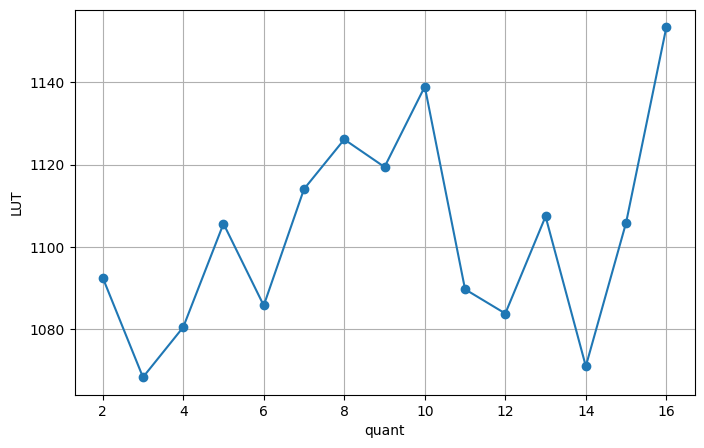

In [71]:
plot_relation("quant", "LUT")

In [62]:
for p in cols_X:

    print(p, end="  ")

    for v in cols_Y:
        agg = group_table(p, v)
        name, _, _ = get_best_fit_func(agg["key"], agg["mean"])
        
        print(f"{v}: {name} | ", end="")
    
    print()

ch_in  BRAM_18K: linear | DSP: exponencial | FF: linear | LUT: linear | avg_total_cycles: linear | estimated_clock_period: linear | 
ch_out  BRAM_18K: exponencial | DSP: linear | FF: linear | LUT: linear | avg_total_cycles: linear | estimated_clock_period: quad | 
dim  BRAM_18K: linear | DSP: linear | FF: linear | LUT: linear | avg_total_cycles: quad | estimated_clock_period: quad | 
kernel  BRAM_18K: linear | DSP: quad | FF: linear | LUT: linear | avg_total_cycles: linear | estimated_clock_period: quad | 
padding  BRAM_18K: quad | 

/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, X, y)
/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, X, y)
/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, X, y)
/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, X, y)
/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, X, y)
/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, X, y)
/tmp/ipykernel_3957091/1440602734.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = 

DSP: linear | FF: linear | LUT: linear | avg_total_cycles: quad | estimated_clock_period: quad | 
quant  BRAM_18K: linear | DSP: quad | FF: quad | LUT: exponencial | avg_total_cycles: quad | estimated_clock_period: linear | 
stride  BRAM_18K: exponencial | DSP: exponencial | FF: exponencial | LUT: exponencial | avg_total_cycles: inv_sq | estimated_clock_period: exponencial | 


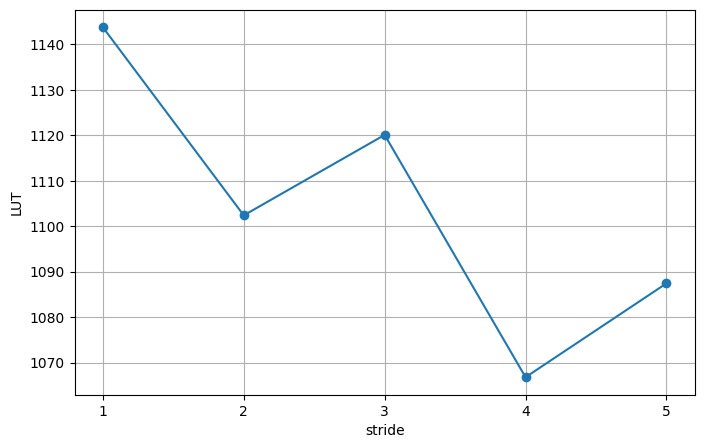

In [66]:
plot_relation("stride", "LUT")

In [14]:
def simple_explore_one_to_one_box_plot(a, b):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))

    sns.boxplot(x=df[a], y=df[b])

    plt.xlabel(a)
    plt.ylabel(b)
    plt.title(f"{a} -> {b} (Boxplot)")

    plt.grid(True)
    plt.show()

In [16]:
def simple_explore_one_to_one(figure_name, a, b, func, name_x, name_y):

    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker


    # média por valor de 'a'
    nova_tabela = (
        df.groupby(a)[b]
        .mean()
        .reset_index(name="media")
    )

    # ordena para garantir gráfico correto
    nova_tabela = nova_tabela.sort_values(a)

    # name, func, params = get_best_fit_func(nova_tabela[a], nova_tabela["media"])

    # print(f"Best Function to make regression: {name}  - {params}")

    # y_func = func(nova_tabela[a], *params)

    # def linear(x, a, b):
    #     return a*x + b

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(nova_tabela[a], nova_tabela["media"], marker="o")

    if func is not None:
    
        func_params, _ = curve_fit(func, nova_tabela[a], nova_tabela["media"])
        x_smooth = np.linspace(nova_tabela[a].min(), nova_tabela[a].max(), 200)
        y_func = func(x_smooth, *func_params)
        plt.plot(x_smooth, y_func, linestyle="--")

    ax = plt.gca()

    ax.xaxis.set_major_locator(ticker.MaxNLocator(
        integer=True,
        nbins=10  # máximo de ticks visíveis
    ))

    plt.xlabel(name_x)
    plt.ylabel(name_y)

    plt.grid(True)
    plt.savefig(f"sbcci_images/{figure_name}.pdf")
    plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

def aux_one_to_one(ax, sub_chart_name, a, b, func, name_x, name_y):

    # média por valor de 'a'
    nova_tabela = (
        df.groupby(a)[b]
        .mean()
        .reset_index(name="media")
    )

    # ordena
    nova_tabela = nova_tabela.sort_values(a)

    # gráfico principal
    ax.plot(nova_tabela[a], nova_tabela["media"], marker="o")

    # curva ajustada (se existir)
    if func is not None:
        func_params, _ = curve_fit(
            func,
            nova_tabela[a],
            nova_tabela["media"]
        )

        x_smooth = np.linspace(
            nova_tabela[a].min(),
            nova_tabela[a].max(),
            200
        )

        y_func = func(x_smooth, *func_params)
        ax.plot(x_smooth, y_func, linestyle="--")

    # ticks inteiros no eixo X
    ax.xaxis.set_major_locator(
        ticker.MaxNLocator(integer=True, nbins=10)
    )

    # títulos e labels corretos
    ax.set_title(sub_chart_name, loc="left", fontweight="bold")
    ax.set_xlabel(name_x)
    ax.set_ylabel(name_y)

    ax.grid(True)

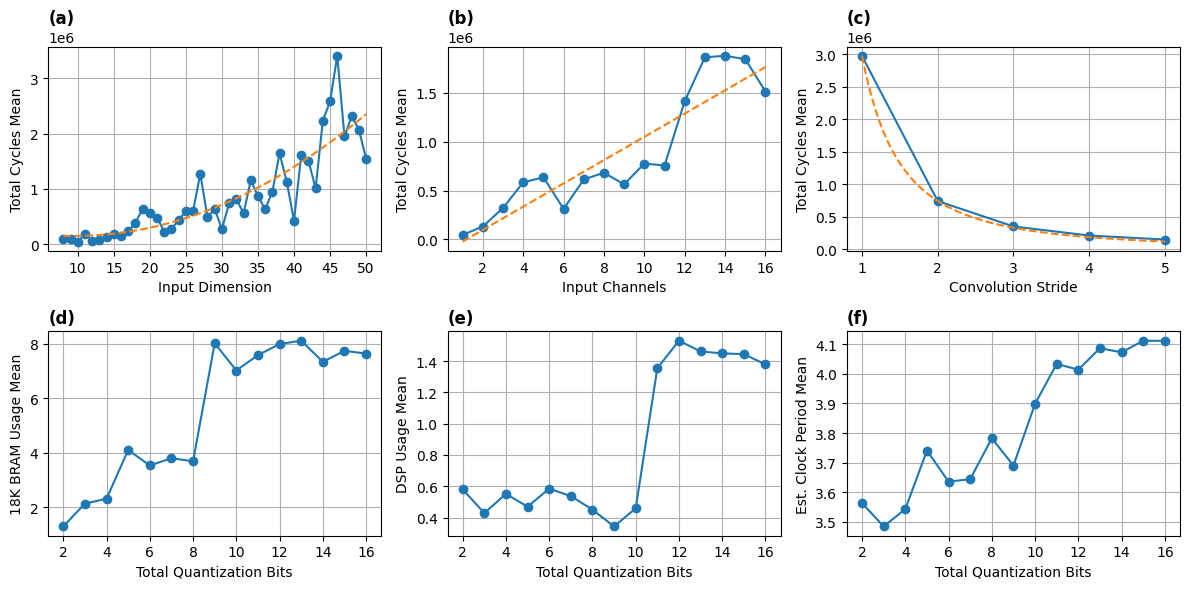

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

labels = [("(a)", "dim", "avg_total_cycles", lambda x, a, b, c: a * x * x + b * x + c, "Input Dimension", "Total Cycles Mean"), 
          ("(b)", "ch_in", "avg_total_cycles", lambda x, a, b: a * x + b, "Input Channels", "Total Cycles Mean"),
          ("(c)", "stride", "avg_total_cycles", lambda x, a: a / (x * x), "Convolution Stride", "Total Cycles Mean"),
          ("(d)", "quant", "BRAM_18K", None, "Total Quantization Bits", "18K BRAM Usage Mean"),
          ("(e)", "quant", "DSP", None, "Total Quantization Bits", "DSP Usage Mean"),
          ("(f)", "quant", "estimated_clock_period", None, "Total Quantization Bits", "Est. Clock Period Mean")]

for ax, label in zip(axes.flat, labels):
    # ax.plot([1, 2, 3], [1, 4, 9])  # <- substitua pelo seu gráfico
    # ax.set_title(label, loc="left", fontweight="bold")
    aux_one_to_one(ax, *label)

plt.tight_layout()

plt.savefig("sbcci_images/figura_6graficos.pdf", bbox_inches="tight")
plt.show()

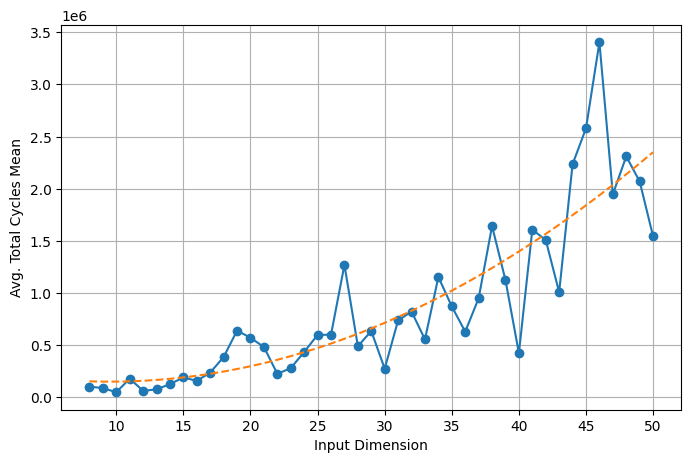

In [17]:
simple_explore_one_to_one("dim_cycles","dim", "avg_total_cycles", lambda x, a, b, c: a * x * x + b * x + c, "Input Dimension", "Avg. Total Cycles Mean")

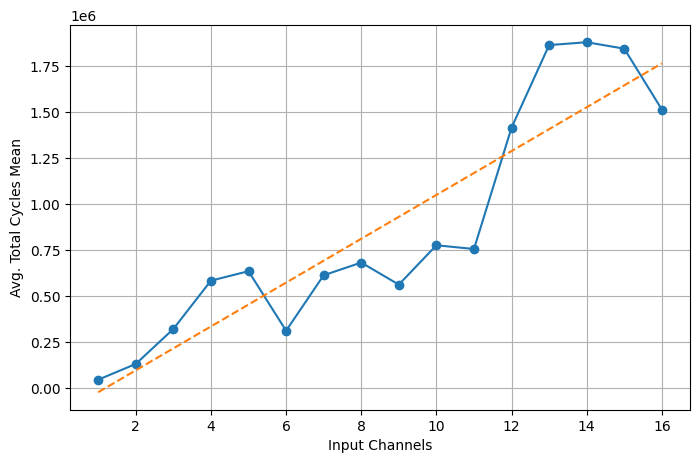

In [18]:
simple_explore_one_to_one("ch_in_cycles", "ch_in", "avg_total_cycles", lambda x, a, b: a * x + b, "Input Channels", "Avg. Total Cycles Mean")

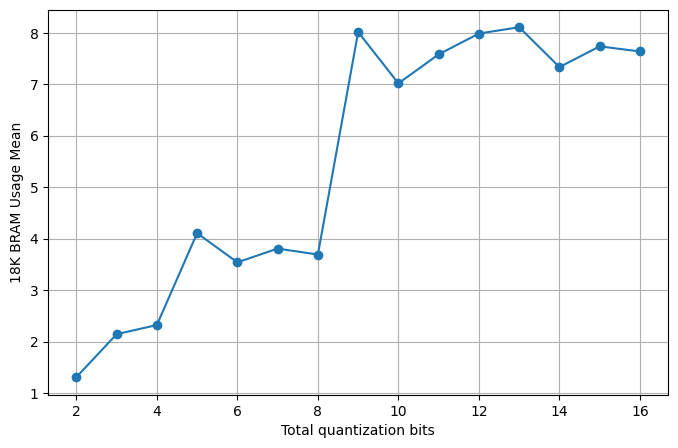

In [22]:
simple_explore_one_to_one("quant_bram", "quant", "BRAM_18K", None, "Total quantization bits", "18K BRAM Usage Mean")

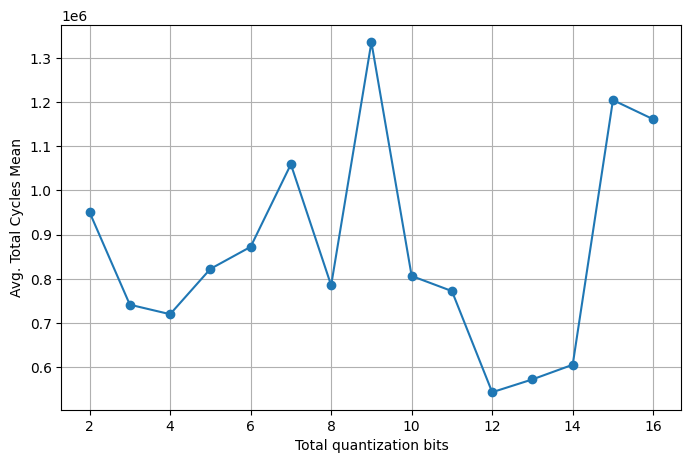

In [27]:
simple_explore_one_to_one("quant_cycles", "quant", "avg_total_cycles", None, "Total quantization bits", "Avg. Total Cycles Mean")

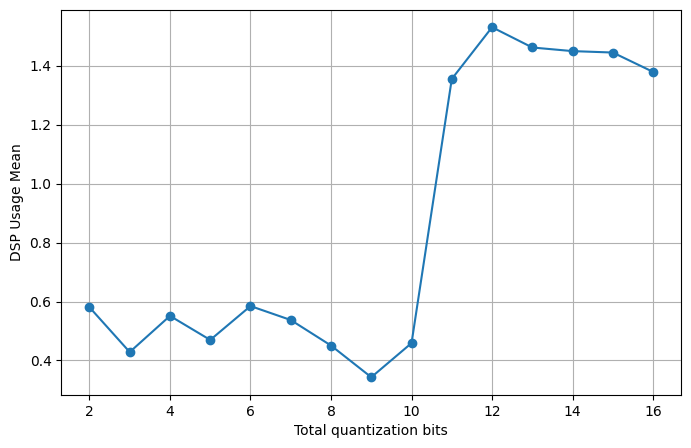

In [25]:
simple_explore_one_to_one("quant_dsp", "quant", "DSP", None, "Total quantization bits", "DSP Usage Mean")

## curvatura relativa de função

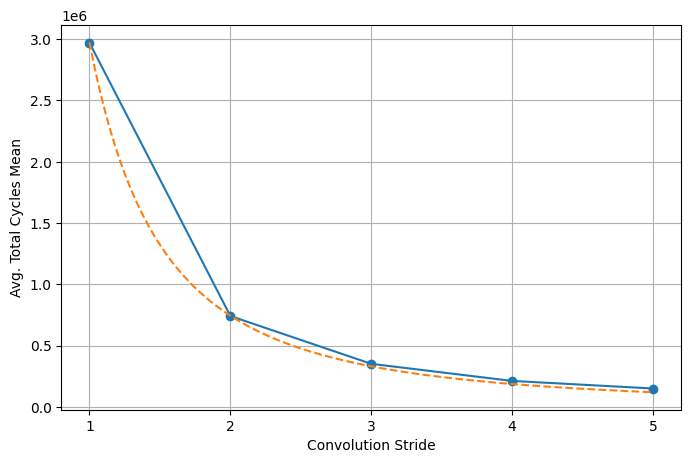

In [20]:
simple_explore_one_to_one("stride_cycles", "stride", "avg_total_cycles", lambda x, a: a / (x * x), "Convolution Stride", "Avg. Total Cycles Mean")

In [112]:
def explore_one_to_one(a, b, n_bins=5):

    import pandas as pd
    import matplotlib.pyplot as plt

    # média original por valor de 'a'
    nova_tabela = (
        df.groupby(a)[b]
        .mean()
        .reset_index(name="media")
    )

    # ordena (importante para plot e bins)
    nova_tabela = nova_tabela.sort_values(a)

    # cria bins
    nova_tabela["grupo"] = pd.cut(nova_tabela[a], bins=n_bins)

    # agrega dentro dos bins (suavização)
    suavizado = (
        nova_tabela.groupby("grupo", observed=True)
        .agg({
            a: "mean",
            "media": "mean"
        })
        .reset_index(drop=True)
    )

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(suavizado[a], suavizado["media"], marker="o")

    plt.xlabel(a)
    plt.ylabel(f"{b} mean")
    plt.title(f"{a} -> {b} (suavizado em {n_bins} bins)")

    plt.grid(True)
    plt.show()

In [122]:
def explore_one_to_one_with_std(a, b, n_bins=5):
    import pandas as pd
    import matplotlib.pyplot as plt

    # cria bins diretamente no df original
    df_binned = df.copy()
    df_binned["grupo"] = pd.cut(df_binned[a], bins=n_bins)

    # print(df_binned)

    # calcula média e desvio padrão dentro de cada bin
    suavizado = (
        df_binned.groupby("grupo", observed=True)
        .agg({
            a: "mean",      # posição média do bin
            b: ["mean", "std"]  # média e desvio padrão
        })
    )

    # flatten do MultiIndex das colunas
    suavizado.columns = ["quant_mean", "media", "std"]
    suavizado = suavizado.reset_index(drop=True)

    # plot com barras de erro
    plt.figure(figsize=(8, 5))
    plt.errorbar(
        suavizado["quant_mean"],
        suavizado["media"],
        yerr=suavizado["std"],
        fmt='o-',
        capsize=5,
        ecolor='red',
        markerfacecolor='blue'
    )

    plt.xlabel(a)
    plt.ylabel(f"{b} mean ± std")
    plt.title(f"{a} -> {b} (suavizado em {n_bins} bins)")
    plt.grid(True)
    plt.show()

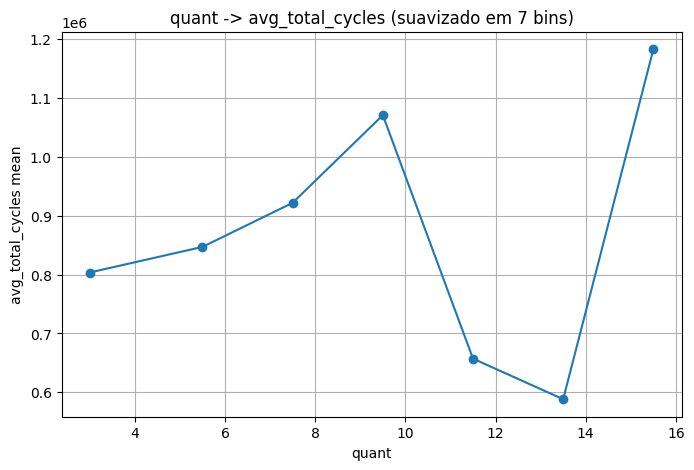

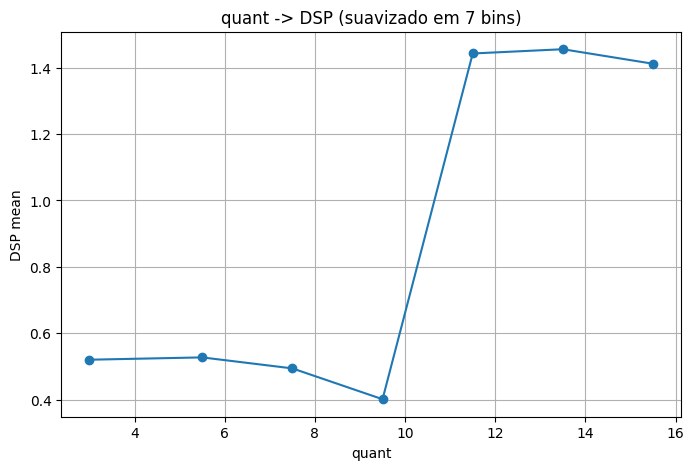

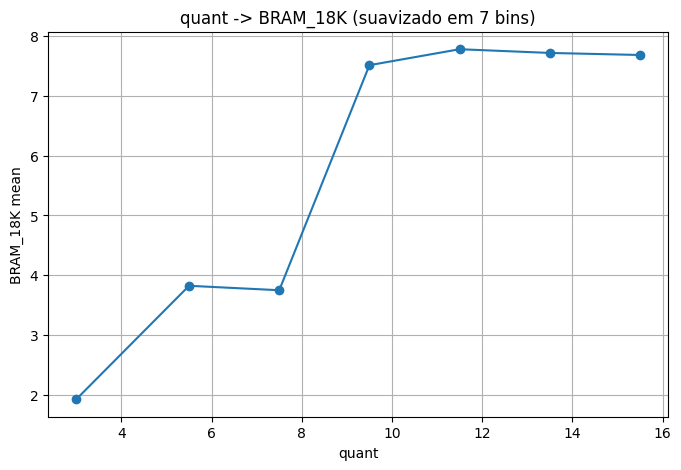

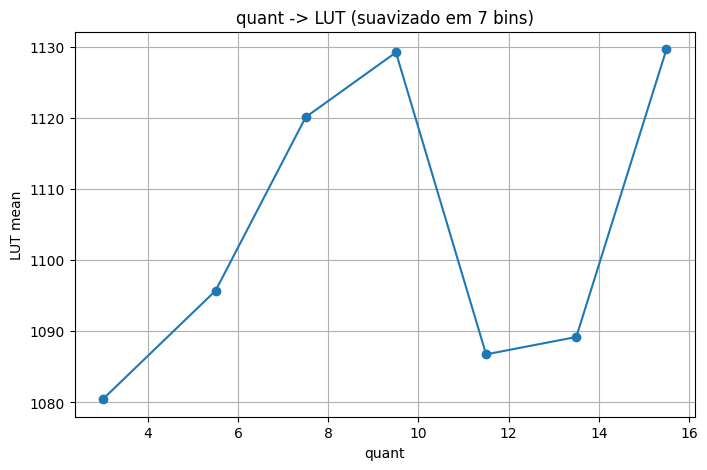

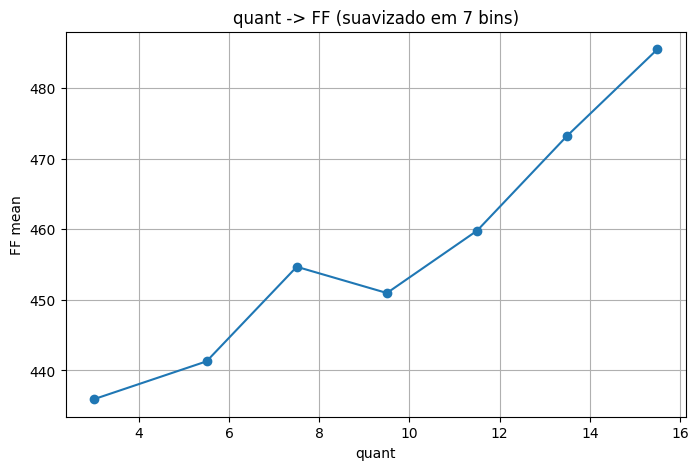

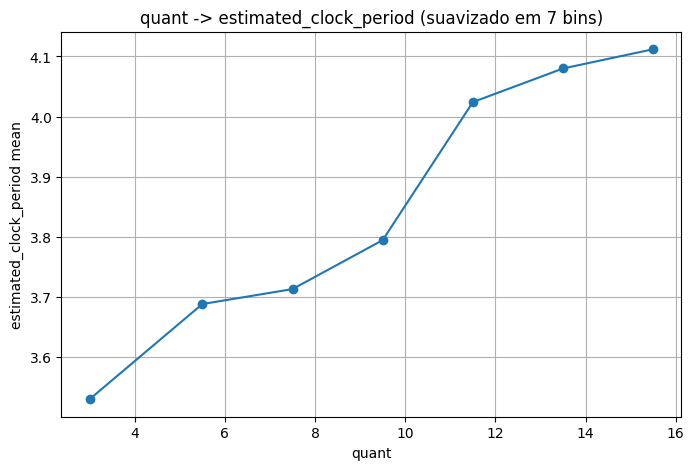

In [130]:
explore_one_to_one("quant", "avg_total_cycles", 7)
explore_one_to_one("quant", "DSP", 7)
explore_one_to_one("quant", "BRAM_18K", 7)
explore_one_to_one("quant", "LUT", 7)
explore_one_to_one("quant", "FF", 7)
explore_one_to_one("quant", "estimated_clock_period", 7)

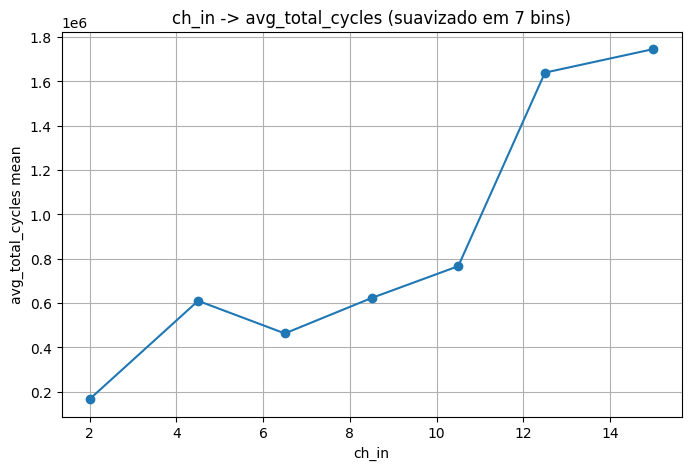

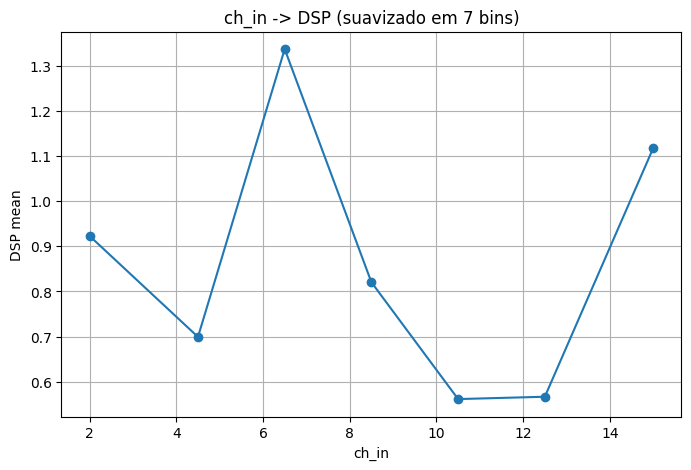

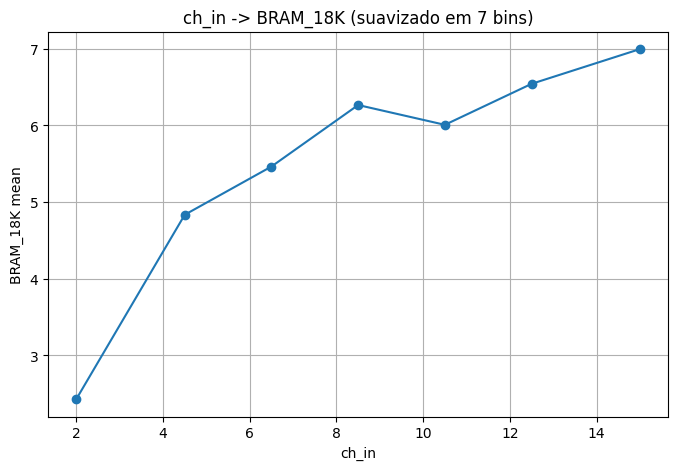

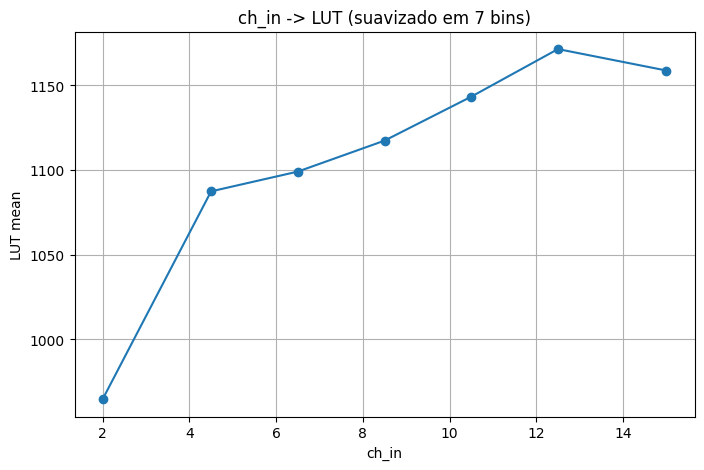

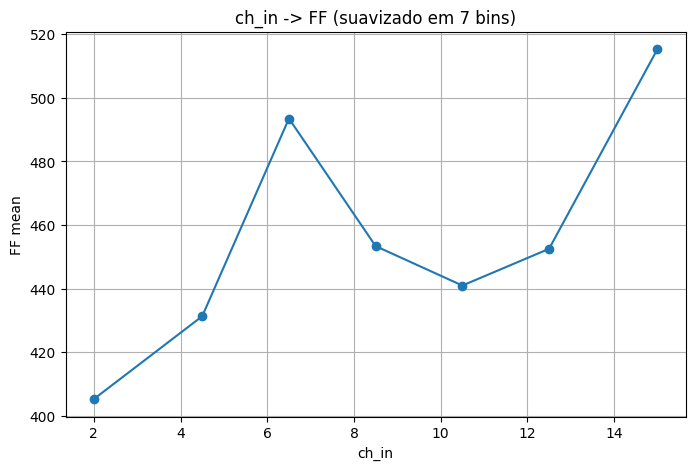

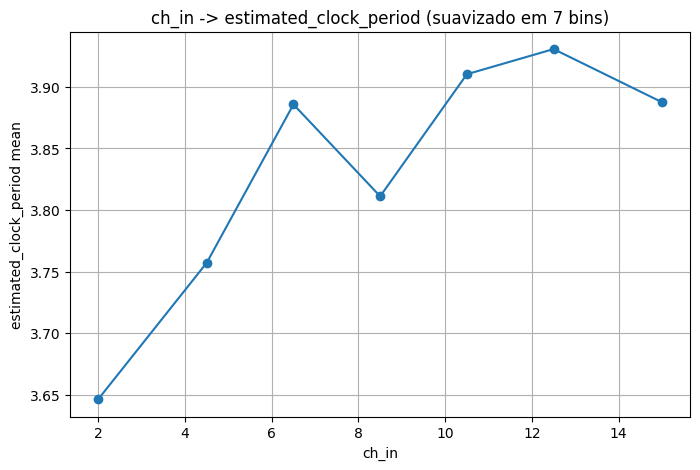

In [131]:
explore_one_to_one("ch_in", "avg_total_cycles", 7)
explore_one_to_one("ch_in", "DSP", 7)
explore_one_to_one("ch_in", "BRAM_18K", 7)
explore_one_to_one("ch_in", "LUT", 7)
explore_one_to_one("ch_in", "FF", 7)
explore_one_to_one("ch_in", "estimated_clock_period", 7)

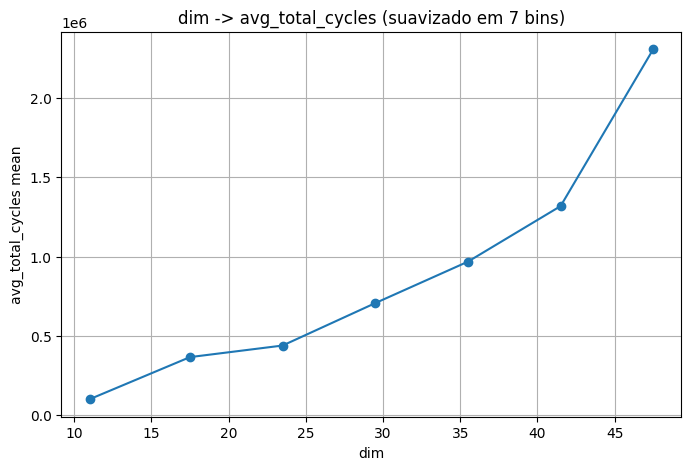

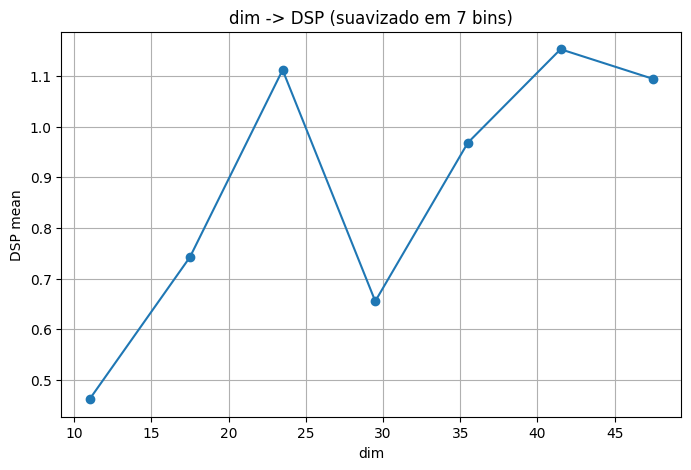

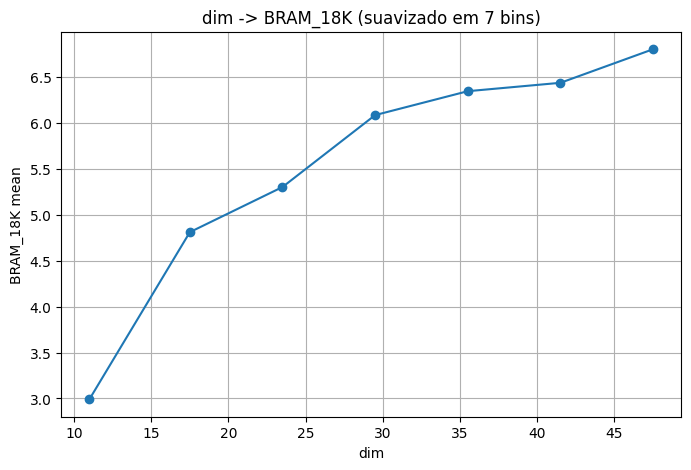

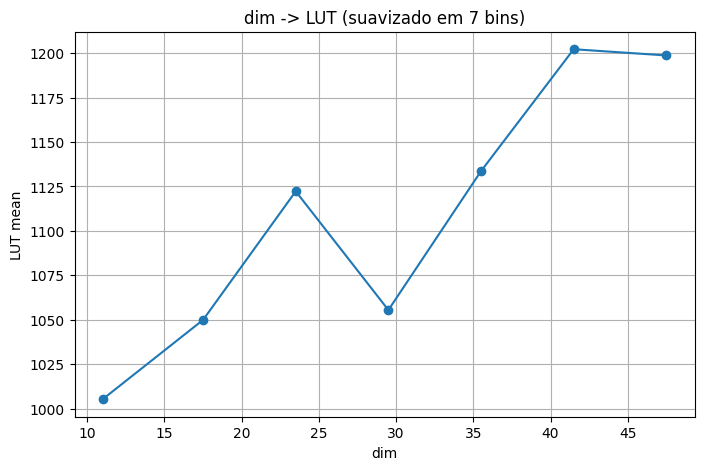

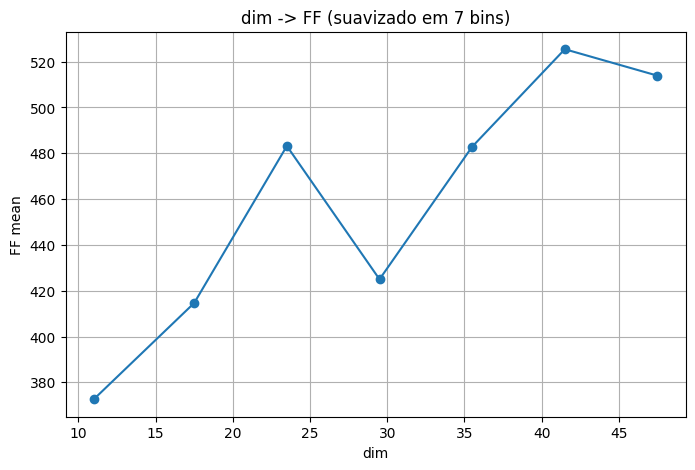

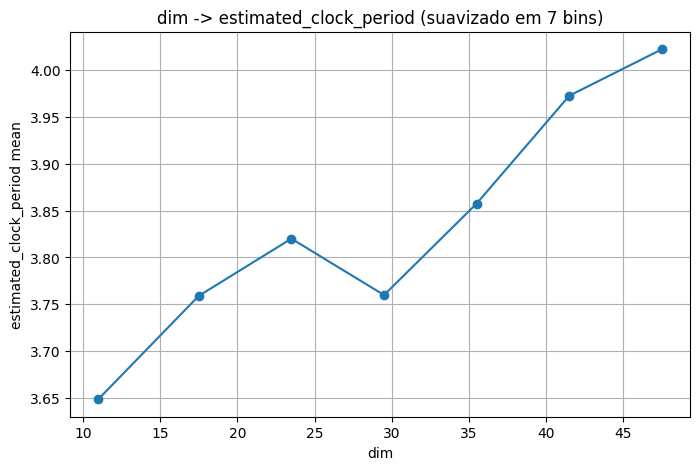

In [132]:
explore_one_to_one("dim", "avg_total_cycles", 7)
explore_one_to_one("dim", "DSP", 7)
explore_one_to_one("dim", "BRAM_18K", 7)
explore_one_to_one("dim", "LUT", 7)
explore_one_to_one("dim", "FF", 7)
explore_one_to_one("dim", "estimated_clock_period", 7)

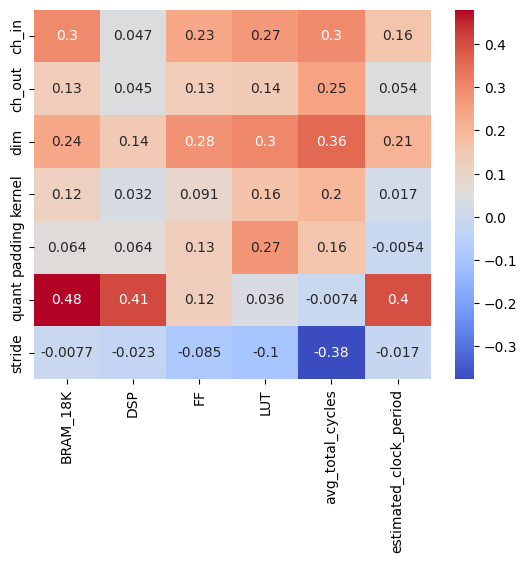

In [28]:
sns.heatmap(conv_resource.astype(float), annot=True, cmap="coolwarm")
plt.show()

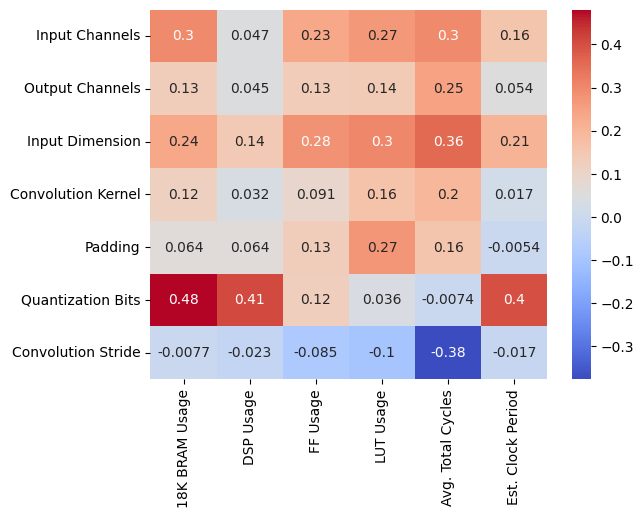

In [31]:
conv_resource.index = ["Input Channels", "Output Channels", "Input Dimension", "Convolution Kernel", "Padding", "Quantization Bits", "Convolution Stride"]
conv_resource.columns = ["18K BRAM Usage", "DSP Usage", "FF Usage", "LUT Usage", "Avg. Total Cycles", "Est. Clock Period"]

sns.heatmap(conv_resource.astype(float), annot=True, cmap="coolwarm")
plt.show()

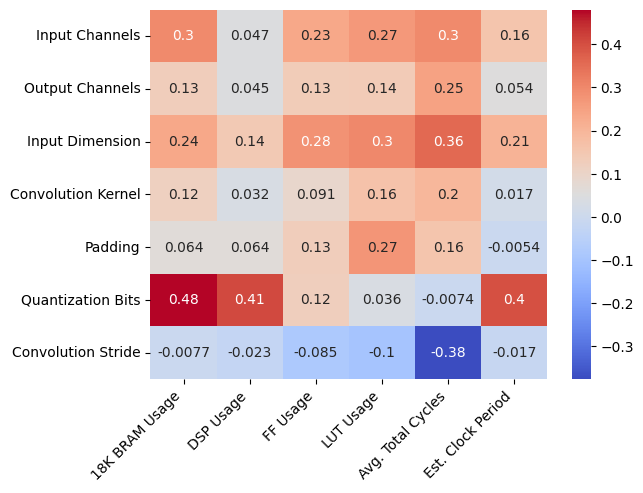

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.heatmap(
    conv_resource.astype(float),
    annot=True,
    cmap="coolwarm",
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.savefig("sbcci_images/mat_corr.pdf", bbox_inches="tight")
plt.show()

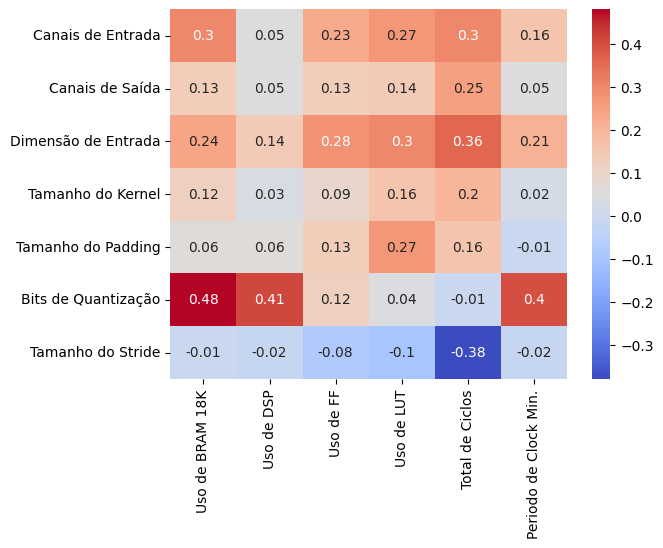

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

conv_resource.index = ["Canais de Entrada", "Canais de Saída", "Dimensão de Entrada", "Tamanho do Kernel", "Tamanho do Padding", "Bits de Quantização", "Tamanho do Stride"]
conv_resource.columns = ["Uso de BRAM 18K", "Uso de DSP", "Uso de FF", "Uso de LUT", "Total de Ciclos", "Periodo de Clock Min."]

sns.heatmap(conv_resource.astype(float), annot=True, cmap="coolwarm")
plt.show()

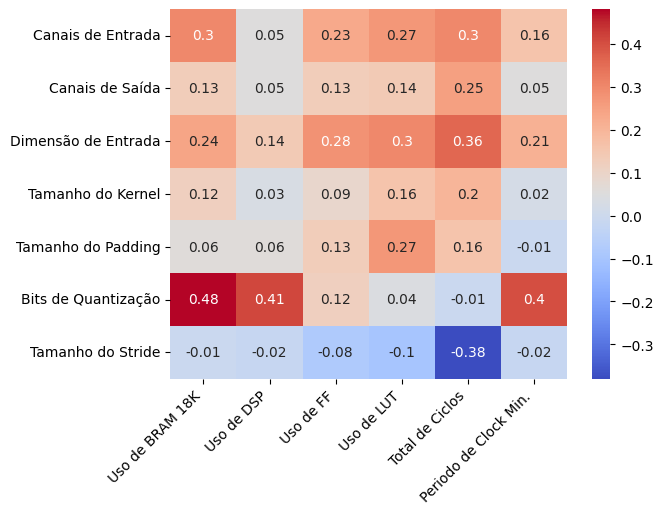

In [29]:
ax = sns.heatmap(
    conv_resource.astype(float),
    annot=True,
    cmap="coolwarm",
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.savefig("sbcci_images/mat_corr_pt.pdf", bbox_inches="tight")
plt.show()